# Credit Risk Prediction Using Machine Learning

Single notebook for analysis, preprocessing, training, evaluation, and SHAP. The Flask app loads the saved pipeline only.

**Target:** `Approved_Flag` (P1–P4), documented as priority levels. **Join:** `case_study1` ⋈ `case_study2` on `PROSPECTID`. **Leakage:** `Credit_Score` and `PROSPECTID` are excluded from predictors.

---

## 1. Project Introduction

Credit risk is the probability that a borrower fails to repay. Lenders lose money on high-risk approvals and lose volume if they reject good applicants. This project maps bureau and application fields to a **multiclass priority category** so screening is consistent and inspectable.

**Interview:** Supervised classification on tabular bureau data; the label is a business priority bucket, not a causal default event.


## 2. Business Problem

51,336 prospects, two complementary tables, one ID. Predict `Approved_Flag` ∈ {P1, P2, P3, P4}. The dictionary does not define which code is “best.” P2 is ~63% of rows, so accuracy alone is misleading. `Credit_Score` tracks the flag closely and is **not** used as a feature.


## 3. Import Libraries

**What / why / how:** Load Excel, plot, and train with a fixed seed. **Interview:** Fit transformers on train only via `Pipeline` + `ColumnTransformer`.


In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_colwidth", 110)

RANDOM_STATE = 42
SENTINEL = -99999
DATASET_DIR = Path("dataset")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
PIPELINE_PATH = MODEL_DIR / "credit_risk_pipeline.pkl"
print("pandas", pd.__version__, "| shap", shap.__version__)


pandas 2.3.3 | shap 0.52.0


## 4. Load Dataset

Inspect sheet names, then load explicitly.


In [2]:
workbook_info = {}
for name in ["Features_Target_Description.xlsx", "case_study1.xlsx", "case_study2.xlsx"]:
    path = DATASET_DIR / name
    xl = pd.ExcelFile(path)
    workbook_info[name] = xl.sheet_names
    print(f"{name}: {xl.sheet_names}")

feature_dictionary = pd.read_excel(DATASET_DIR / "Features_Target_Description.xlsx", sheet_name="Sheet1")
case_study1 = pd.read_excel(DATASET_DIR / "case_study1.xlsx", sheet_name="case_study1")
case_study2 = pd.read_excel(DATASET_DIR / "case_study2.xlsx", sheet_name="case_study2")
print(feature_dictionary.shape, case_study1.shape, case_study2.shape)


Features_Target_Description.xlsx: ['Sheet1']
case_study1.xlsx: ['case_study1']
case_study2.xlsx: ['case_study2']
(88, 3) (51336, 26) (51336, 62)


## 5. Understand the Dataset

Confirm Phase 1: 1:1 IDs, complementary columns, no Pandas NaNs (sentinels instead).


In [12]:
# assert case_study1["PROSPECTID"].is_unique and case_study2["PROSPECTID"].is_unique
# assert set(case_study1["PROSPECTID"]) == set(case_study2["PROSPECTID"])
print("shared columns", sorted(set(case_study1.columns) & set(case_study2.columns)))
print("cs1 nulls", int(case_study1.isna().sum().sum()), "dups", int(case_study1.duplicated().sum()))
print("cs2 nulls", int(case_study2.isna().sum().sum()), "dups", int(case_study2.duplicated().sum()))
print(case_study1.dtypes.value_counts().to_dict())
print(case_study2.dtypes.value_counts().to_dict())


shared columns ['PROSPECTID']
cs1 nulls 0 dups 0
cs2 nulls 0 dups 0
{dtype('int64'): 20, dtype('float64'): 6}
{dtype('int64'): 46, dtype('float64'): 10, dtype('O'): 6}


## 6. Data Dictionary / Feature Description


In [13]:
dictionary_clean = feature_dictionary.copy()
dictionary_clean["feature_group"] = dictionary_clean["Case_study1 table"].ffill()
dictionary_clean = dictionary_clean.dropna(subset=["Variable Name"]).rename(
    columns={"Variable Name": "variable_name", "Description": "description"}
)[["feature_group", "variable_name", "description"]]
display(dictionary_clean)
print("blank descriptions:", dictionary_clean.loc[dictionary_clean["description"].isna(), "variable_name"].tolist())


,feature_group,variable_name,description
0,Internal,Total_TL,Total trade lines/accounts in Bureau
1,Internal,Tot_Closed_TL,Total closed trade lines/accounts
2,Internal,Tot_Active_TL,Total active accounts
3,Internal,Total_TL_opened_L6M,Total accounts opened in last 6 Months
4,Internal,Tot_TL_closed_L6M,Total accounds closes in last 6 months
...,...,...,...
83,External,GL_Flag,Gold Loan Flag
84,External,last_prod_enq2,Lates product enquired for
85,External,first_prod_enq2,First productd enquired for
86,External,Credit_Score,Applicant's credit score


blank descriptions: ['GENDER', 'NETMONTHLYINCOME']


## 7. Data Cleaning

**What:** Merge on ID, recode `-99999` to NaN, drop identifier and `Credit_Score`.  
**Why:** Same prospects, complementary fields; sentinel is coded missing; score would leak the label.  
**How:** Inner join; `replace`. High-missing columns are dropped later using **train** rates only.  
**Interview:** Leakage is using information unavailable at decision time or that is the label in disguise.


In [14]:
raw = case_study1.merge(case_study2, on="PROSPECTID", how="inner", validate="one_to_one")
print("merged", raw.shape)

raw_numeric = raw.select_dtypes(include=["number"]).columns
sentinel_rate = (raw[raw_numeric] == SENTINEL).mean().sort_values(ascending=False)
print(sentinel_rate[sentinel_rate > 0].head(25))

cleaned = raw.replace(SENTINEL, np.nan).copy()
leakage_or_id = ["PROSPECTID", "Credit_Score"]
cleaned = cleaned.drop(columns=leakage_or_id)
print("after dropping ID/score", cleaned.shape)
print("NaNs introduced from sentinel:", int(cleaned.isna().sum().sum()))


merged (51336, 87)
CC_utilization                  0.927926
PL_utilization                  0.865572
time_since_first_deliquency     0.700269
max_delinquency_level           0.700269
time_since_recent_deliquency    0.700269
max_unsec_exposure_inPct        0.451496
max_deliq_6mts                  0.251091
max_deliq_12mts                 0.211002
CC_enq_L12m                     0.123130
PL_enq_L12m                     0.123130
PL_enq_L6m                      0.123130
enq_L12m                        0.123130
enq_L6m                         0.123130
enq_L3m                         0.123130
PL_enq                          0.123130
time_since_recent_enq           0.123130
CC_enq_L6m                      0.123130
tot_enq                         0.123130
CC_enq                          0.123130
time_since_recent_payment       0.083587
pct_currentBal_all_TL           0.001403
Age_Oldest_TL                   0.000779
Age_Newest_TL                   0.000779
dtype: float64
after dropping ID/score

## 8. Exploratory Data Analysis

Interpretations sit under each plot. Plots use the analysis table; they do not fit encoders.


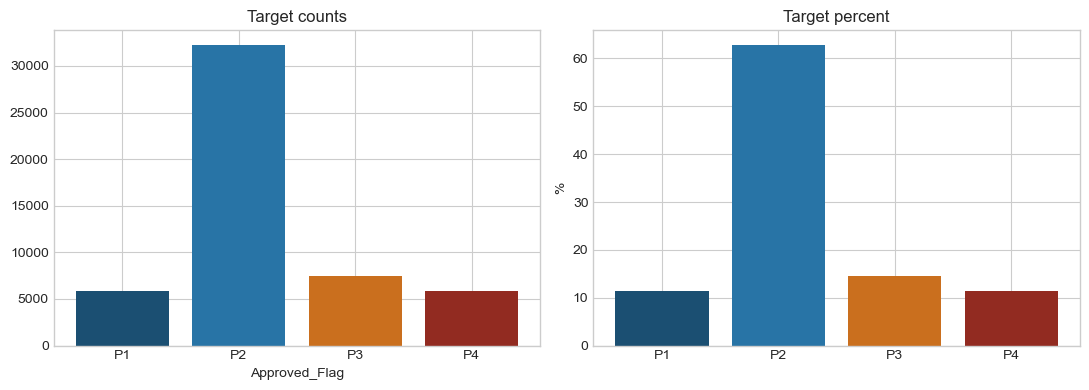

{'P1': 11.3, 'P2': 62.72, 'P3': 14.52, 'P4': 11.46}


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["P1", "P2", "P3", "P4"]
counts = cleaned["Approved_Flag"].value_counts().reindex(order)
axes[0].bar(counts.index, counts.values, color=["#1b4f72", "#2874a6", "#ca6f1e", "#922b21"])
axes[0].set_title("Target counts")
axes[0].set_xlabel("Approved_Flag")
pct = counts / counts.sum() * 100
axes[1].bar(pct.index, pct.values, color=["#1b4f72", "#2874a6", "#ca6f1e", "#922b21"])
axes[1].set_title("Target percent")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()
print((pct.round(2)).to_dict())


*P2 dominates (~63%). A majority classifier would look accurate and fail on P1/P3/P4. Use macro-F1 and class-wise recall.*


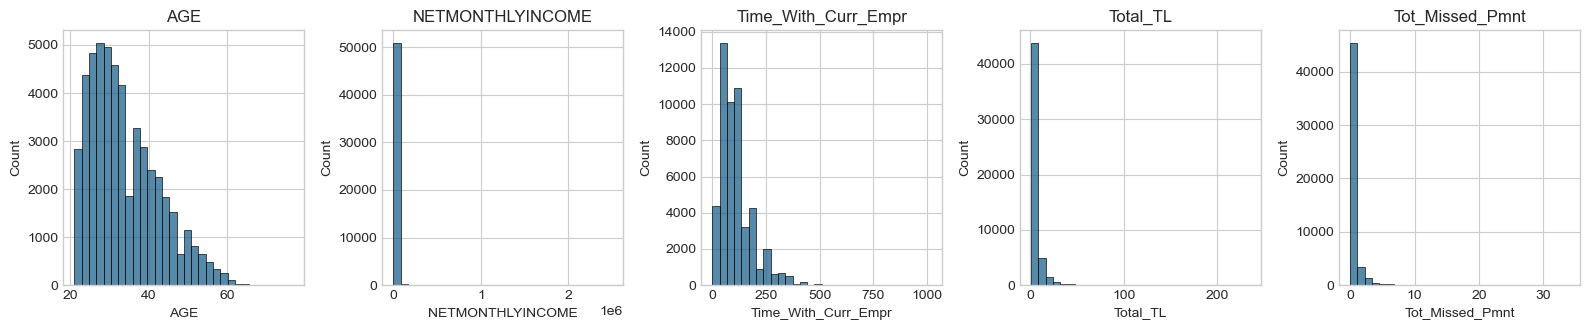

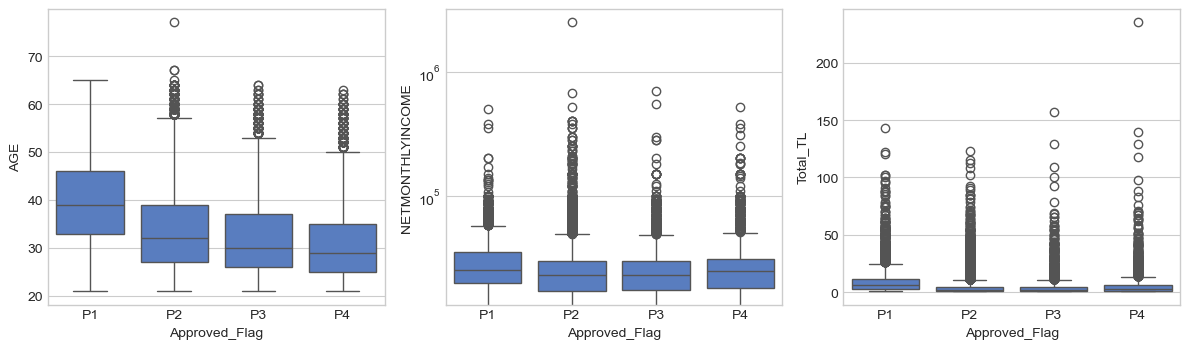

In [16]:
demo_cols = ["AGE", "NETMONTHLYINCOME", "Time_With_Curr_Empr", "Total_TL", "Tot_Missed_Pmnt"]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, col in zip(axes, demo_cols):
    sns.histplot(cleaned[col].dropna(), bins=30, ax=ax, color="#1f618d")
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, col in zip(axes, ["AGE", "NETMONTHLYINCOME", "Total_TL"]):
    sns.boxplot(data=cleaned, x="Approved_Flag", y=col, order=order, ax=ax)
    if col == "NETMONTHLYINCOME":
        ax.set_yscale("log")
plt.tight_layout()
plt.show()


*Age is adult (21–77). Income is right-skewed with zeros; log-scale boxplots avoid one tail hiding the rest. Trade-line counts are discrete and sparse at high values — we will not delete those tails without a data-error reason.*


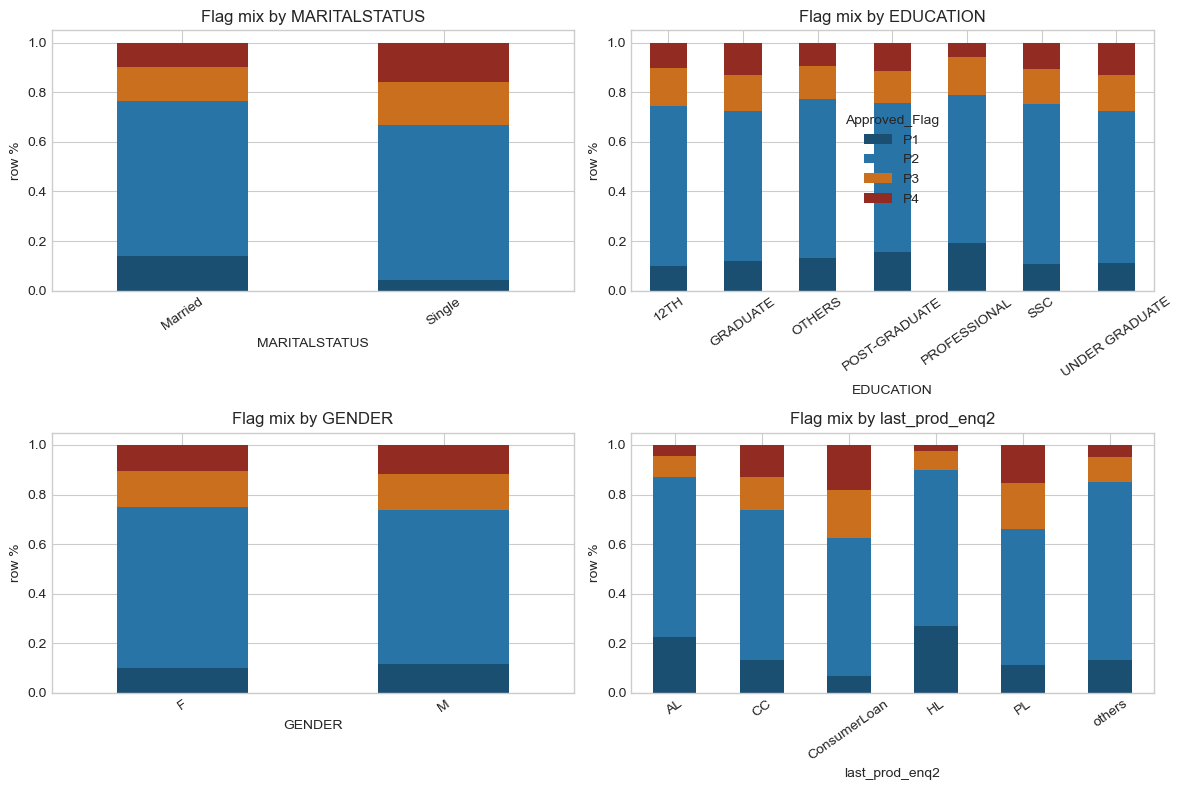

In [17]:
cat_plot_cols = ["MARITALSTATUS", "EDUCATION", "GENDER", "last_prod_enq2"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_plot_cols):
    ct = pd.crosstab(cleaned[col], cleaned["Approved_Flag"], normalize="index").reindex(columns=order)
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#1b4f72", "#2874a6", "#ca6f1e", "#922b21"], legend=ax is axes[0, 1])
    ax.set_title(f"Flag mix by {col}")
    ax.set_ylabel("row %")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


*Category mix shifts with education and last product enquiry. Gender/marital gaps may be proxy effects; we keep them as recorded fields but do not treat them as causal.*


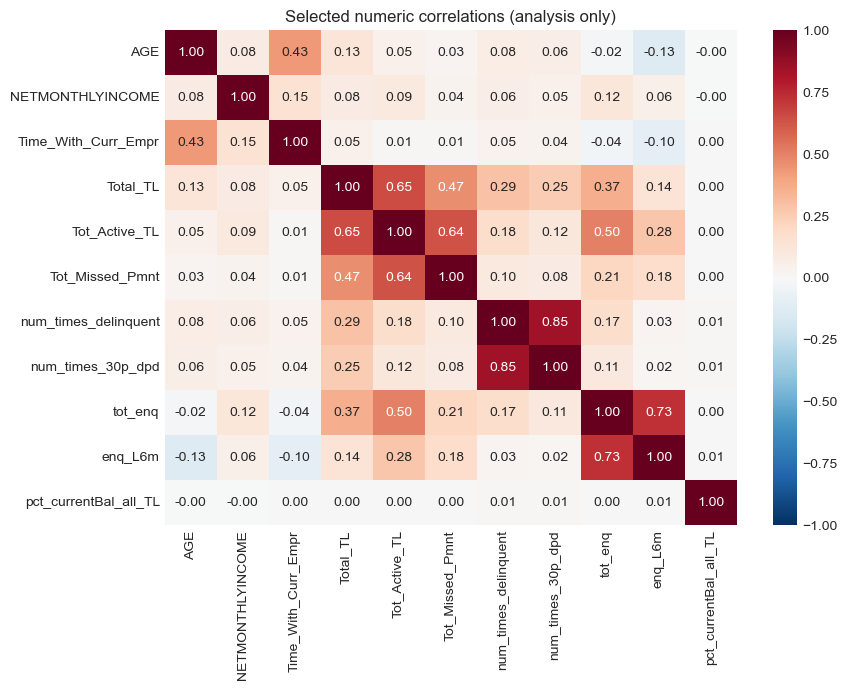

In [19]:
corr_cols = [
    "AGE", "NETMONTHLYINCOME", "Time_With_Curr_Empr", "Total_TL", "Tot_Active_TL",
    "Tot_Missed_Pmnt", "num_times_delinquent", "num_times_30p_dpd", "tot_enq",
    "enq_L6m", "pct_currentBal_all_TL",
]
corr = cleaned[corr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Selected numeric correlations (analysis only)")
plt.tight_layout()
plt.show()


*Enquiry windows and delinquency counts are correlated with their siblings. After the split we drop near-duplicate columns (|r| > 0.95) using train data only.*


## 9. Feature Engineering

Row-wise ratios only (no train statistics). Skip DTI/LTI — the tables have no installment or original loan-amount field.

1. `missed_pmnt_per_tl` = missed payments / accounts. Normalizes missed payments by bureau size.  
2. `delinquent_per_tl` = delinquency events / accounts. Same idea for delinquency.  
3. `recent_enq_share` = last-3-month enquiries / last-12-month enquiries. Recent search intensity.


In [20]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    tl = out["Total_TL"].fillna(0)
    out["missed_pmnt_per_tl"] = out["Tot_Missed_Pmnt"] / (tl + 1)
    out["delinquent_per_tl"] = out["num_times_delinquent"] / (tl + 1)
    enq12 = out["enq_L12m"]
    out["recent_enq_share"] = out["enq_L3m"] / (enq12.replace(0, np.nan))
    return out

featured = add_engineered_features(cleaned)
print(featured[["missed_pmnt_per_tl", "delinquent_per_tl", "recent_enq_share"]].describe().T)


                      count      mean       std  min  25%       50%       75%  \
missed_pmnt_per_tl  51336.0  0.092670  0.160461  0.0  0.0  0.000000  0.142857   
delinquent_per_tl   51336.0  0.298608  0.850880  0.0  0.0  0.000000  0.181818   
recent_enq_share    35642.0  0.429128  0.388435  0.0  0.0  0.388889  0.750000   

                          max  
missed_pmnt_per_tl   0.833333  
delinquent_per_tl   16.500000  
recent_enq_share     1.000000  


## 10. Target Variable Analysis

`y = Approved_Flag` (4 classes). `X` = remaining columns. Classes are priority levels per the dictionary — not renamed.


In [21]:
TARGET = "Approved_Flag"
y = featured[TARGET]
X = featured.drop(columns=[TARGET])
print(y.value_counts().reindex(order))
print("feature matrix", X.shape)
categorical_all = X.select_dtypes(include=["object"]).columns.tolist()
numeric_all = X.select_dtypes(exclude=["object"]).columns.tolist()
print("categoricals", categorical_all)
print("n numeric", len(numeric_all))


Approved_Flag
P1     5803
P2    32199
P3     7452
P4     5882
Name: count, dtype: int64
feature matrix (51336, 87)
categoricals ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
n numeric 82


## 11. Train-Test Split

**Why stratify:** Preserve the 63/15/11/11 mix in both sides so minority classes appear in the test set. Test is unused until final evaluation.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print("train %\n", (y_train.value_counts(normalize=True) * 100).round(2).reindex(order))
print("test %\n", (y_test.value_counts(normalize=True) * 100).round(2).reindex(order))


(41068, 87) (10268, 87)
train %
 Approved_Flag
P1    11.30
P2    62.72
P3    14.51
P4    11.46
Name: proportion, dtype: float64
test %
 Approved_Flag
P1    11.31
P2    62.72
P3    14.52
P4    11.45
Name: proportion, dtype: float64


## 12. Data Preprocessing

## 13. Handling Class Imbalance

## 14. Feature Selection

Missingness and correlation filters are **fit on train**. Class imbalance is handled with **balanced class / sample weights**, not SMOTE (mixed types, 51k rows, weights stay inside a sklearn pipeline).


In [23]:
def drop_high_missing(train_df, test_df, threshold=0.50):
    miss = train_df.isna().mean()
    drop_cols = miss[miss > threshold].index.tolist()
    return train_df.drop(columns=drop_cols), test_df.drop(columns=drop_cols), drop_cols

def drop_high_correlation(train_df, test_df, threshold=0.95):
    num_cols = train_df.select_dtypes(include=["number"]).columns
    corr_abs = train_df[num_cols].corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > threshold)]
    return train_df.drop(columns=drop_cols), test_df.drop(columns=drop_cols), drop_cols

X_train_fs, X_test_fs, dropped_missing = drop_high_missing(X_train, X_test, 0.50)
X_train_fs, X_test_fs, dropped_corr = drop_high_correlation(X_train_fs, X_test_fs, 0.95)
print("dropped >50% missing (train):", dropped_missing)
print("dropped |r|>0.95 (train):", dropped_corr)

numeric_features = X_train_fs.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_fs.select_dtypes(include=["object"]).columns.tolist()

numeric_tree = Pipeline([("imputer", SimpleImputer(strategy="median"))])
numeric_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

tree_preprocess = ColumnTransformer([
    ("num", numeric_tree, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])
linear_preprocess = ColumnTransformer([
    ("num", numeric_linear, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

print("numeric", len(numeric_features), "categorical", categorical_features)


dropped >50% missing (train): ['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'CC_utilization', 'PL_utilization']
dropped |r|>0.95 (train): ['Tot_Closed_TL', 'pct_closed_tl', 'num_std_12mts', 'pct_of_active_TLs_ever', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever']
numeric 71 categorical ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


## 15. Baseline Machine Learning Models

## 16. Model Comparison

Same split. Trees unscaled; logistic regression scaled. Metrics from execution (weighted + macro; ROC-AUC / PR-AUC one-vs-rest).


In [24]:
def classification_metrics(y_true, y_pred, y_proba, labels):
    y_bin = label_binarize(np.asarray(y_true), classes=list(labels))
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ROC_AUC_ovr": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted", labels=labels),
        "PR_AUC_ovr": average_precision_score(y_bin, y_proba, average="weighted"),
    }

xgb_label_map = {cls: i for i, cls in enumerate(sorted(y_train.unique()))}
inv_xgb_label_map = {i: cls for cls, i in xgb_label_map.items()}
y_train_xgb = y_train.map(xgb_label_map)
y_test_xgb = y_test.map(xgb_label_map)
xgb_sample_weight = compute_sample_weight("balanced", y_train_xgb)
class_labels = sorted(y_train.unique())

models = {
    "Logistic Regression": (
        Pipeline([
            ("prep", clone(linear_preprocess)),
            ("model", LogisticRegression(max_iter=400, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        False,
    ),
    "Decision Tree": (
        Pipeline([
            ("prep", clone(tree_preprocess)),
            ("model", DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        False,
    ),
    "Random Forest": (
        Pipeline([
            ("prep", clone(tree_preprocess)),
            ("model", RandomForestClassifier(
                n_estimators=120, max_depth=16, min_samples_leaf=4,
                class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ]),
        False,
    ),
    "XGBoost": (
        Pipeline([
            ("prep", clone(tree_preprocess)),
            ("model", XGBClassifier(
                n_estimators=120, max_depth=5, learning_rate=0.08,
                subsample=0.85, colsample_bytree=0.85,
                objective="multi:softprob", eval_metric="mlogloss",
                n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
            )),
        ]),
        True,
    ),
}

comparison_rows = []
fitted_models = {}
for name, (pipe, is_xgb) in models.items():
    if is_xgb:
        pipe.fit(X_train_fs, y_train_xgb, model__sample_weight=xgb_sample_weight)
        pred_idx = pipe.predict(X_test_fs)
        proba = pipe.predict_proba(X_test_fs)
        pred = pd.Series(pred_idx).map(inv_xgb_label_map).to_numpy()
        y_true_eval, y_proba_eval = y_test, proba
    else:
        pipe.fit(X_train_fs, y_train)
        pred = pipe.predict(X_test_fs)
        y_proba_eval = pipe.predict_proba(X_test_fs)
        y_true_eval = y_test
        # align proba columns to alphabetical class_labels used by roc_auc
    fitted_models[name] = pipe
    metrics = classification_metrics(y_true_eval, pred, y_proba_eval, labels=class_labels)
    metrics["Model"] = name
    comparison_rows.append(metrics)
    print(name, {k: round(v, 4) for k, v in metrics.items() if k != "Model"})

comparison_table = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_table.round(4))


Logistic Regression {'Accuracy': 0.6872, 'Precision_weighted': 0.7525, 'Recall_weighted': 0.6872, 'F1_weighted': 0.7047, 'Precision_macro': 0.6206, 'Recall_macro': 0.7037, 'F1_macro': 0.6463, 'ROC_AUC_ovr': 0.8786, 'PR_AUC_ovr': 0.8041}
Decision Tree {'Accuracy': 0.6964, 'Precision_weighted': 0.7637, 'Recall_weighted': 0.6964, 'F1_weighted': 0.7157, 'Precision_macro': 0.6295, 'Recall_macro': 0.7036, 'F1_macro': 0.6523, 'ROC_AUC_ovr': 0.8481, 'PR_AUC_ovr': 0.74}
Random Forest {'Accuracy': 0.7532, 'Precision_weighted': 0.7823, 'Recall_weighted': 0.7532, 'F1_weighted': 0.7625, 'Precision_macro': 0.6679, 'Recall_macro': 0.7342, 'F1_macro': 0.6948, 'ROC_AUC_ovr': 0.9157, 'PR_AUC_ovr': 0.8401}
XGBoost {'Accuracy': 0.73, 'Precision_weighted': 0.7956, 'Recall_weighted': 0.73, 'F1_weighted': 0.7462, 'Precision_macro': 0.665, 'Recall_macro': 0.7603, 'F1_macro': 0.6952, 'ROC_AUC_ovr': 0.9197, 'PR_AUC_ovr': 0.8504}


,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,ROC_AUC_ovr,PR_AUC_ovr
Model,,,,,,,,,
Logistic Regression,0.6872,0.7525,0.6872,0.7047,0.6206,0.7037,0.6463,0.8786,0.8041
Decision Tree,0.6964,0.7637,0.6964,0.7157,0.6295,0.7036,0.6523,0.8481,0.7400
Random Forest,0.7532,0.7823,0.7532,0.7625,0.6679,0.7342,0.6948,0.9157,0.8401
XGBoost,0.7300,0.7956,0.7300,0.7462,0.6650,0.7603,0.6952,0.9197,0.8504


## 17. XGBoost Model

Decision tree → sequential boosting of residuals → gradient boosting → XGBoost (regularized, column/row subsample, hist splits). Strong on tabular data; still can overfit and is not automatically the winner. Selection uses the comparison table.


In [25]:
selection_score = comparison_table["F1_macro"]
best_baseline_name = selection_score.idxmax()
print("Best baseline by macro-F1:", best_baseline_name)
print(comparison_table.loc[best_baseline_name].round(4))


Best baseline by macro-F1: XGBoost
Accuracy              0.7300
Precision_weighted    0.7956
Recall_weighted       0.7300
F1_weighted           0.7462
Precision_macro       0.6650
Recall_macro          0.7603
F1_macro              0.6952
ROC_AUC_ovr           0.9197
PR_AUC_ovr            0.8504
Name: XGBoost, dtype: float64


## 18. Hyperparameter Tuning

`RandomizedSearchCV` on the selected family, **train only**, stratified CV, optimize `f1_macro`. Test set still held out.


In [26]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tune_xgb = best_baseline_name == "XGBoost"

if tune_xgb:
    search_pipe = Pipeline([
        ("prep", clone(tree_preprocess)),
        ("model", XGBClassifier(
            objective="multi:softprob", eval_metric="mlogloss",
            n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
        )),
    ])
    param_distributions = {
        "model__n_estimators": [80, 120, 180],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.05, 0.08, 0.12],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma": [0, 0.1, 0.3],
    }
    search = RandomizedSearchCV(
        search_pipe, param_distributions, n_iter=8, scoring="f1_macro",
        cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1,
    )
    search.fit(X_train_fs, y_train_xgb, model__sample_weight=xgb_sample_weight)
    tuned_pipeline = search.best_estimator_
    print("best params", search.best_params_)
    print("best CV f1_macro", round(search.best_score_, 4))
else:
    base = fitted_models[best_baseline_name]
    param_distributions = {
        "Logistic Regression": {"model__C": [0.1, 0.5, 1.0, 2.0]},
        "Decision Tree": {"model__max_depth": [8, 12, 16, None], "model__min_samples_leaf": [1, 4, 8]},
        "Random Forest": {
            "model__n_estimators": [80, 120, 180],
            "model__max_depth": [10, 16, 22, None],
            "model__min_samples_leaf": [1, 4, 8],
        },
    }[best_baseline_name]
    search = RandomizedSearchCV(
        clone(base), param_distributions, n_iter=8, scoring="f1_macro",
        cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1,
    )
    search.fit(X_train_fs, y_train)
    tuned_pipeline = search.best_estimator_
    print("best params", search.best_params_)
    print("best CV f1_macro", round(search.best_score_, 4))

final_is_xgb = isinstance(tuned_pipeline.named_steps["model"], XGBClassifier)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
best params {'model__subsample': 0.85, 'model__n_estimators': 180, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.12, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
best CV f1_macro 0.7074


## 19. Cross Validation

Mean and std of macro-F1 on train folds. Then test score once.


In [27]:
cv_scores = []
for fold_train_idx, fold_val_idx in cv.split(X_train_fs, y_train if not final_is_xgb else y_train_xgb):
    fold_model = clone(tuned_pipeline)
    X_tr, X_va = X_train_fs.iloc[fold_train_idx], X_train_fs.iloc[fold_val_idx]
    if final_is_xgb:
        y_tr, y_va = y_train_xgb.iloc[fold_train_idx], y_train_xgb.iloc[fold_val_idx]
        sw = compute_sample_weight("balanced", y_tr)
        fold_model.fit(X_tr, y_tr, model__sample_weight=sw)
        pred = fold_model.predict(X_va)
        cv_scores.append(f1_score(y_va, pred, average="macro"))
    else:
        y_tr, y_va = y_train.iloc[fold_train_idx], y_train.iloc[fold_val_idx]
        fold_model.fit(X_tr, y_tr)
        pred = fold_model.predict(X_va)
        cv_scores.append(f1_score(y_va, pred, average="macro"))
cv_scores = np.array(cv_scores)
print("CV f1_macro mean", round(cv_scores.mean(), 4), "std", round(cv_scores.std(), 4), "folds", np.round(cv_scores, 4))


CV f1_macro mean 0.7075 std 0.0021 folds [0.7098 0.708  0.7046]


## 20. Final Model Evaluation


In [28]:
if final_is_xgb:
    y_pred_final = pd.Series(tuned_pipeline.predict(X_test_fs)).map(inv_xgb_label_map).to_numpy()
    y_proba_final = tuned_pipeline.predict_proba(X_test_fs)
else:
    y_pred_final = tuned_pipeline.predict(X_test_fs)
    y_proba_final = tuned_pipeline.predict_proba(X_test_fs)

final_metrics = classification_metrics(y_test, y_pred_final, y_proba_final, labels=class_labels)
print(pd.Series(final_metrics).round(4))
print()
print(classification_report(y_test, y_pred_final, digits=4))
print("test f1_macro", round(final_metrics["F1_macro"], 4), "| CV mean", round(cv_scores.mean(), 4))
class_order = [inv_xgb_label_map[int(i)] for i in tuned_pipeline.named_steps["model"].classes_] if final_is_xgb else list(tuned_pipeline.named_steps["model"].classes_)
print("class_order", class_order)


Accuracy              0.7651
Precision_weighted    0.7989
Recall_weighted       0.7651
F1_weighted           0.7759
Precision_macro       0.6899
Recall_macro          0.7544
F1_macro              0.7152
ROC_AUC_ovr           0.9234
PR_AUC_ovr            0.8542
dtype: float64

              precision    recall  f1-score   support

          P1     0.7102    0.8992    0.7936      1161
          P2     0.9192    0.7876    0.8483      6440
          P3     0.4119    0.5553    0.4730      1491
          P4     0.7181    0.7755    0.7457      1176

    accuracy                         0.7651     10268
   macro avg     0.6899    0.7544    0.7152     10268
weighted avg     0.7989    0.7651    0.7759     10268

test f1_macro 0.7152 | CV mean 0.7075
class_order ['P1', 'P2', 'P3', 'P4']


## 21. Confusion Matrix

Rows = true, columns = predicted. Off-diagonals are confusions between priority buckets.


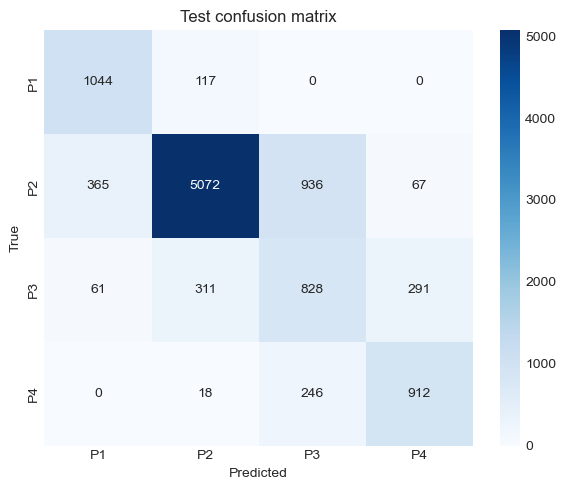

,pred_P1,pred_P2,pred_P3,pred_P4
true_P1,1044,117,0,0
true_P2,365,5072,936,67
true_P3,61,311,828,291
true_P4,0,18,246,912


In [29]:
cm = confusion_matrix(y_test, y_pred_final, labels=order)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in order], columns=[f"pred_{c}" for c in order])
display(cm_df)


## 22. ROC-AUC / PR-AUC

Weighted OVR because classes are imbalanced. PR-AUC is more sensitive to minority precision.


ROC-AUC (weighted OVR): 0.9234
PR-AUC  (weighted OVR): 0.8542


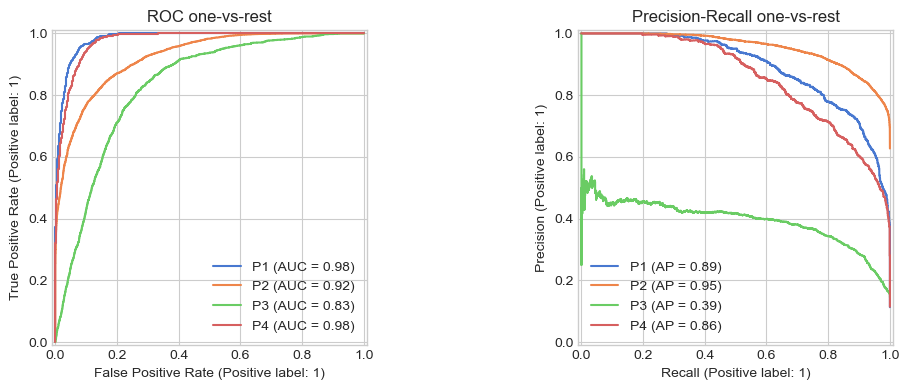

In [30]:
print("ROC-AUC (weighted OVR):", round(final_metrics["ROC_AUC_ovr"], 4))
print("PR-AUC  (weighted OVR):", round(final_metrics["PR_AUC_ovr"], 4))
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize

final_estimator = tuned_pipeline.named_steps["model"]
model_classes = list(final_estimator.classes_)
y_bin = label_binarize(y_test, classes=order)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, cls in enumerate(order):
    proba_col = model_classes.index(xgb_label_map[cls] if final_is_xgb else cls)
    RocCurveDisplay.from_predictions(y_bin[:, i], y_proba_final[:, proba_col], name=cls, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_bin[:, i], y_proba_final[:, proba_col], name=cls, ax=axes[1])
axes[0].set_title("ROC one-vs-rest")
axes[1].set_title("Precision-Recall one-vs-rest")
plt.tight_layout()
plt.show()


## 23. Feature Importance

Gain/weight importance is association inside the model, not causality. Permutation importance on a train subsample (n=2500) as a check.


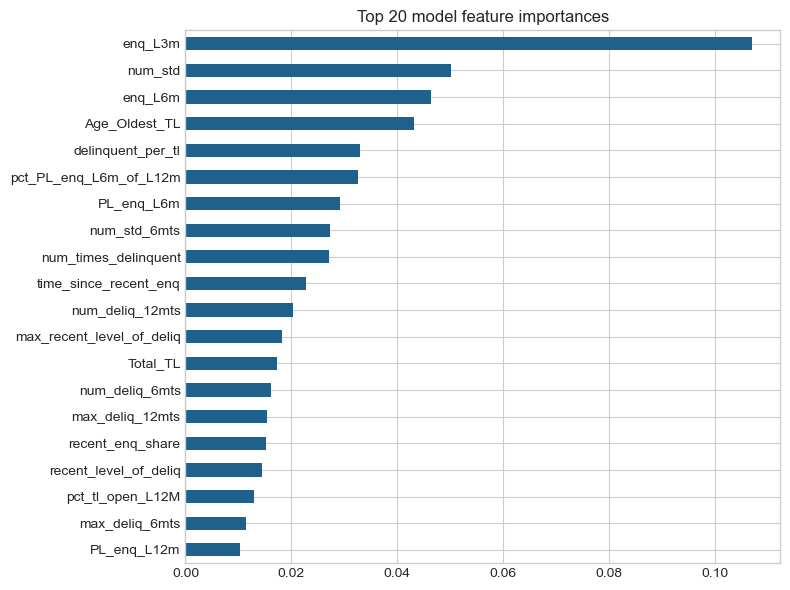

,importance
enq_L3m,0.107019
num_std,0.050228
enq_L6m,0.046386
Age_Oldest_TL,0.043130
delinquent_per_tl,0.032955
pct_PL_enq_L6m_of_L12m,0.032641
PL_enq_L6m,0.029287
num_std_6mts,0.027374
num_times_delinquent,0.027175
time_since_recent_enq,0.022700


permutation importance (raw input columns)


,perm_f1_macro
Age_Oldest_TL,0.216936
enq_L3m,0.120612
time_since_recent_enq,0.061189
num_std_6mts,0.036246
delinquent_per_tl,0.035576
pct_PL_enq_L6m_of_L12m,0.023363
num_std,0.021936
Age_Newest_TL,0.021534
recent_enq_share,0.017971
Time_With_Curr_Empr,0.016399


In [31]:
ohe = tuned_pipeline.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
feature_names = numeric_features + ohe.get_feature_names_out(categorical_features).tolist()
estimator = tuned_pipeline.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    imp = pd.Series(estimator.feature_importances_, index=feature_names).sort_values(ascending=False)
else:
    imp = pd.Series(np.abs(estimator.coef_).mean(axis=0), index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
imp.head(20).iloc[::-1].plot(kind="barh", color="#1f618d")
plt.title("Top 20 model feature importances")
plt.tight_layout()
plt.show()
display(imp.head(15).to_frame("importance"))

perm_sample = X_train_fs.sample(n=min(2500, len(X_train_fs)), random_state=RANDOM_STATE)
if final_is_xgb:
    perm_y = y_train_xgb.loc[perm_sample.index]
else:
    perm_y = y_train.loc[perm_sample.index]
perm = permutation_importance(
    tuned_pipeline, perm_sample, perm_y, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro"
)
perm_s = pd.Series(perm.importances_mean, index=X_train_fs.columns).sort_values(ascending=False)
print("permutation importance (raw input columns)")
display(perm_s.head(15).to_frame("perm_f1_macro"))


## 24. SHAP Explainability

SHAP attributes the model’s prediction to features. It is not a causal graph. Background sample of 400 rows; explain 200 test rows.


<Figure size 900x600 with 0 Axes>

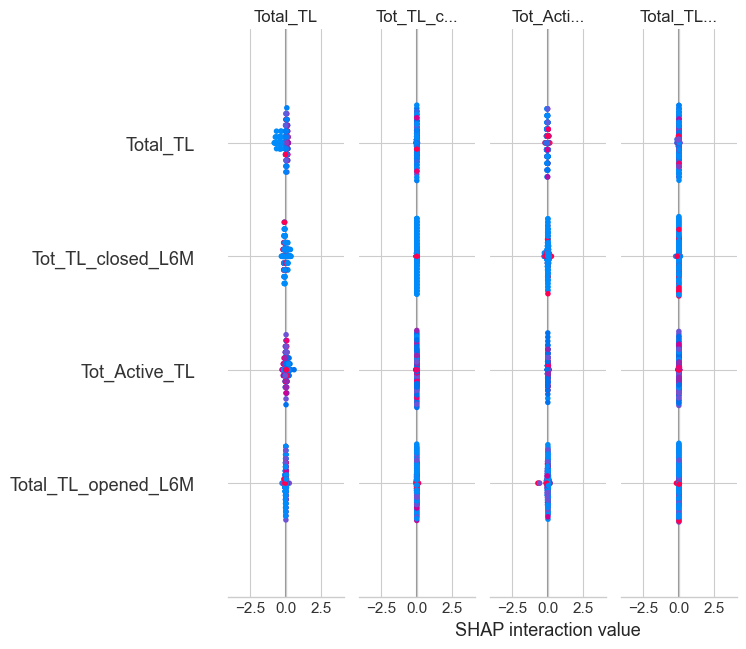

In [32]:
background = X_train_fs.sample(n=min(400, len(X_train_fs)), random_state=RANDOM_STATE)
explain_x = X_test_fs.sample(n=min(200, len(X_test_fs)), random_state=RANDOM_STATE)
prep = tuned_pipeline.named_steps["prep"]
X_bg = prep.transform(background)
X_ex = prep.transform(explain_x)

if final_is_xgb or isinstance(estimator, (RandomForestClassifier, DecisionTreeClassifier)):
    explainer = shap.TreeExplainer(estimator, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X_ex)
else:
    explainer = shap.LinearExplainer(estimator, X_bg)
    shap_values = explainer.shap_values(X_ex)

plt.figure(figsize=(9, 6))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values, X_ex, feature_names=feature_names, class_names=[inv_xgb_label_map.get(i, i) for i in range(len(shap_values))], show=False)
else:
    shap.summary_plot(shap_values, X_ex, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()


### Individual prediction (one test applicant)


In [33]:
sample_row = X_test_fs.iloc[[0]]
sample_true = y_test.iloc[0]
if final_is_xgb:
    pred_idx = int(tuned_pipeline.predict(sample_row)[0])
    pred_label = inv_xgb_label_map[pred_idx]
    proba = tuned_pipeline.predict_proba(sample_row)[0]
    class_order = [inv_xgb_label_map[i] for i in estimator.classes_]
else:
    pred_label = tuned_pipeline.predict(sample_row)[0]
    proba = tuned_pipeline.predict_proba(sample_row)[0]
    class_order = list(estimator.classes_)

print("true", sample_true, "pred", pred_label)
print("probabilities", {c: round(float(p), 4) for c, p in zip(class_order, proba)})

sv_one = explainer.shap_values(prep.transform(sample_row))
if isinstance(sv_one, list):
    cls_index = class_order.index(pred_label)
    contrib = pd.Series(sv_one[cls_index][0], index=feature_names)
else:
    arr = np.array(sv_one)
    if arr.ndim == 3:
        cls_index = class_order.index(pred_label)
        contrib = pd.Series(arr[0, :, cls_index], index=feature_names)
    else:
        contrib = pd.Series(arr[0], index=feature_names)

top_contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
print("top SHAP contributions for predicted class")
display(top_contrib.to_frame("shap"))


true P3 pred P3
probabilities {'P1': 0.0024, 'P2': 0.2867, 'P3': 0.5816, 'P4': 0.1292}
top SHAP contributions for predicted class


,shap
num_sub,-0.501853
Age_Oldest_TL,-0.252338
num_times_30p_dpd,0.220324
Time_With_Curr_Empr,0.192520
time_since_recent_enq,0.177995
recent_level_of_deliq,0.159878
max_recent_level_of_deliq,0.139229
time_since_recent_payment,-0.137431


## 25. Example Predictions


In [34]:
example = X_test_fs.head(8).copy()
if final_is_xgb:
    example["predicted"] = pd.Series(tuned_pipeline.predict(example.drop(columns=[], errors="ignore"))).map(inv_xgb_label_map).to_numpy()
    example_proba = tuned_pipeline.predict_proba(X_test_fs.head(8))
else:
    example["predicted"] = tuned_pipeline.predict(X_test_fs.head(8))
    example_proba = tuned_pipeline.predict_proba(X_test_fs.head(8))
example["true"] = y_test.head(8).to_numpy()
example["pred_probability"] = example_proba.max(axis=1)
display(example[["true", "predicted", "pred_probability"]])


,true,predicted,pred_probability
12061,P3,P3,0.581570
48052,P2,P3,0.592264
9375,P2,P2,0.971834
15099,P4,P4,0.997023
31712,P2,P2,0.949019
31061,P4,P4,0.909821
48307,P3,P3,0.482784
37972,P1,P1,0.996342


## 26. Save Final Model Pipeline

Bundle preprocessing + estimator + metadata so Flask can render the form and map classes.


In [35]:
category_values = {col: sorted(X_train_fs[col].dropna().astype(str).unique().tolist()) for col in categorical_features}
numeric_bounds = {
    col: {
        "min": float(np.nanmin(X_train_fs[col])),
        "max": float(np.nanmax(X_train_fs[col])),
        "median": float(np.nanmedian(X_train_fs[col])),
    }
    for col in numeric_features
}

artifact = {
    "pipeline": tuned_pipeline,
    "input_columns": list(X_train_fs.columns),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "category_values": category_values,
    "numeric_bounds": numeric_bounds,
    "is_xgboost": final_is_xgb,
    "label_map": xgb_label_map if final_is_xgb else {c: c for c in class_labels},
    "inv_label_map": inv_xgb_label_map if final_is_xgb else {c: c for c in class_labels},
    "class_order": class_order,
    "dropped_missing": dropped_missing,
    "dropped_corr": dropped_corr,
    "dropped_leakage": leakage_or_id,
    "final_metrics": {k: float(v) for k, v in final_metrics.items()},
    "comparison_table": comparison_table.reset_index().to_dict(orient="records"),
    "best_baseline_name": best_baseline_name,
    "cv_mean_f1_macro": float(cv_scores.mean()),
    "cv_std_f1_macro": float(cv_scores.std()),
    "engineered_features": ["missed_pmnt_per_tl", "delinquent_per_tl", "recent_enq_share"],
}

joblib.dump(artifact, PIPELINE_PATH)
print("saved", PIPELINE_PATH.resolve())

loaded = joblib.load(PIPELINE_PATH)
reload_row = X_test_fs.iloc[[0]]
p1 = tuned_pipeline.predict(reload_row)
p2 = loaded["pipeline"].predict(reload_row)
print("reload matches", np.array_equal(p1, p2), "pred", p2)


saved C:\Credit_Risk\models\credit_risk_pipeline.pkl
reload matches True pred [2]


## 27. Final Conclusions

- Two Excel case studies are one prospect table joined on `PROSPECTID`.
- `Approved_Flag` is a four-class priority label; P2 majority.
- `-99999` is coded missing. `Credit_Score` is excluded to avoid leakage.
- Weights used instead of SMOTE. Preprocessing fitted on train only.
- Final model is chosen by **macro-F1**, then tuned with randomized CV.
- SHAP explains the fitted model, not the real world.
- Not production-ready: one dataset, no temporal validation, no fairness/policy review, educational Flask demo.

**Interview line:** *I joined complementary bureau tables, treated sentinels as missing, held out a stratified test set, blocked the credit score as leakage, compared four models on macro-F1, tuned only on train CV, and shipped a sklearn pipeline behind Flask.*
